In [38]:
import re
import numpy as np
import pandas as pd
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic' 
plt.rcParams['axes.unicode_minus'] = False

print("no problem")

no problem


In [24]:
texts = [
    "정부가 내년 최저임금을 3.5% 인상하기로 발표했다.",                    # 문서 1
    "최저임금이 내년에 3.5% 오를 예정이다.",                                # 문서 2
    "노동계는 최저임금 인상률이 너무 낮다고 반발하고 있다.",              # 문서 3
    "손흥민이 오늘 경기에서 멀티골을 기록하며 팀의 승리를 이끌었다.",        # 문서 4
    "토트넘은 손흥민의 활약으로 2대1 승리를 거두었다.",                    # 문서 5
    "오늘 경기에서 손흥민이 두 골을 넣으며 결정적인 역할을 했다.",         # 문서 6
    "전국적으로 폭염 특보가 발령되었으며, 체감 온도는 35도를 넘었다.",        # 문서 7
    "오늘은 올여름 들어 가장 더운 날로, 전국 대부분 지역에 폭염 경보가 내려졌다.",  # 문서 8
    "기상청은 내일도 폭염이 계속될 것이라고 예보했다.",                    # 문서 9
    "무더위로 인한 온열질환자가 증가하고 있다.",                          # 문서 10
]

print("샘플 텍스트:")
for i, text in enumerate(texts, 1):
    print(f"{i}. {text}")

샘플 텍스트:
1. 정부가 내년 최저임금을 3.5% 인상하기로 발표했다.
2. 최저임금이 내년에 3.5% 오를 예정이다.
3. 노동계는 최저임금 인상률이 너무 낮다고 반발하고 있다.
4. 손흥민이 오늘 경기에서 멀티골을 기록하며 팀의 승리를 이끌었다.
5. 토트넘은 손흥민의 활약으로 2대1 승리를 거두었다.
6. 오늘 경기에서 손흥민이 두 골을 넣으며 결정적인 역할을 했다.
7. 전국적으로 폭염 특보가 발령되었으며, 체감 온도는 35도를 넘었다.
8. 오늘은 올여름 들어 가장 더운 날로, 전국 대부분 지역에 폭염 경보가 내려졌다.
9. 기상청은 내일도 폭염이 계속될 것이라고 예보했다.
10. 무더위로 인한 온열질환자가 증가하고 있다.


In [28]:
def preprocess_text(text):
    text = re.sub(r'[^가-힣a-zA-Z0-9\s]', '', text)  # 특수문자 제거
    text = re.sub(r'\s+', ' ', text)  # 공백 정리
    # 숫자 제거
    text = re.sub(r'\d+', '', text)
    

    return text.strip()

preprocessed_texts = [preprocess_text(text) for text in texts]

print("전처리 결과:")
for i, (original, processed) in enumerate(zip(texts, preprocessed_texts), 1):
    print(f"{i}. 원본: {original}")
    print(f"   전처리: {processed}\n")

전처리 결과:
1. 원본: 정부가 내년 최저임금을 3.5% 인상하기로 발표했다.
   전처리: 정부가 내년 최저임금을  인상하기로 발표했다

2. 원본: 최저임금이 내년에 3.5% 오를 예정이다.
   전처리: 최저임금이 내년에  오를 예정이다

3. 원본: 노동계는 최저임금 인상률이 너무 낮다고 반발하고 있다.
   전처리: 노동계는 최저임금 인상률이 너무 낮다고 반발하고 있다

4. 원본: 손흥민이 오늘 경기에서 멀티골을 기록하며 팀의 승리를 이끌었다.
   전처리: 손흥민이 오늘 경기에서 멀티골을 기록하며 팀의 승리를 이끌었다

5. 원본: 토트넘은 손흥민의 활약으로 2대1 승리를 거두었다.
   전처리: 토트넘은 손흥민의 활약으로 대 승리를 거두었다

6. 원본: 오늘 경기에서 손흥민이 두 골을 넣으며 결정적인 역할을 했다.
   전처리: 오늘 경기에서 손흥민이 두 골을 넣으며 결정적인 역할을 했다

7. 원본: 전국적으로 폭염 특보가 발령되었으며, 체감 온도는 35도를 넘었다.
   전처리: 전국적으로 폭염 특보가 발령되었으며 체감 온도는 도를 넘었다

8. 원본: 오늘은 올여름 들어 가장 더운 날로, 전국 대부분 지역에 폭염 경보가 내려졌다.
   전처리: 오늘은 올여름 들어 가장 더운 날로 전국 대부분 지역에 폭염 경보가 내려졌다

9. 원본: 기상청은 내일도 폭염이 계속될 것이라고 예보했다.
   전처리: 기상청은 내일도 폭염이 계속될 것이라고 예보했다

10. 원본: 무더위로 인한 온열질환자가 증가하고 있다.
   전처리: 무더위로 인한 온열질환자가 증가하고 있다



In [29]:
def simple_tokenize(text):
    return text.split()

tokenized_texts = [simple_tokenize(text) for text in preprocessed_texts]

print("토큰화 결과:")
for i, (text, tokens) in enumerate(zip(preprocessed_texts, tokenized_texts), 1):
    print(f"{i}. 텍스트: {text}")
    print(f"   토큰: {tokens}\n")

토큰화 결과:
1. 텍스트: 정부가 내년 최저임금을  인상하기로 발표했다
   토큰: ['정부가', '내년', '최저임금을', '인상하기로', '발표했다']

2. 텍스트: 최저임금이 내년에  오를 예정이다
   토큰: ['최저임금이', '내년에', '오를', '예정이다']

3. 텍스트: 노동계는 최저임금 인상률이 너무 낮다고 반발하고 있다
   토큰: ['노동계는', '최저임금', '인상률이', '너무', '낮다고', '반발하고', '있다']

4. 텍스트: 손흥민이 오늘 경기에서 멀티골을 기록하며 팀의 승리를 이끌었다
   토큰: ['손흥민이', '오늘', '경기에서', '멀티골을', '기록하며', '팀의', '승리를', '이끌었다']

5. 텍스트: 토트넘은 손흥민의 활약으로 대 승리를 거두었다
   토큰: ['토트넘은', '손흥민의', '활약으로', '대', '승리를', '거두었다']

6. 텍스트: 오늘 경기에서 손흥민이 두 골을 넣으며 결정적인 역할을 했다
   토큰: ['오늘', '경기에서', '손흥민이', '두', '골을', '넣으며', '결정적인', '역할을', '했다']

7. 텍스트: 전국적으로 폭염 특보가 발령되었으며 체감 온도는 도를 넘었다
   토큰: ['전국적으로', '폭염', '특보가', '발령되었으며', '체감', '온도는', '도를', '넘었다']

8. 텍스트: 오늘은 올여름 들어 가장 더운 날로 전국 대부분 지역에 폭염 경보가 내려졌다
   토큰: ['오늘은', '올여름', '들어', '가장', '더운', '날로', '전국', '대부분', '지역에', '폭염', '경보가', '내려졌다']

9. 텍스트: 기상청은 내일도 폭염이 계속될 것이라고 예보했다
   토큰: ['기상청은', '내일도', '폭염이', '계속될', '것이라고', '예보했다']

10. 텍스트: 무더위로 인한 온열질환자가 증가하고 있다
   토큰: ['무더위로', '인한', '온열질환자가', '증가하고', '있다']



In [30]:
all_tokens = []
for tokens in tokenized_texts:
    all_tokens.extend(tokens)

vocab_counter = Counter(all_tokens)
vocab = list(vocab_counter.keys())

print(f"전체 어휘 수: {len(vocab)}")
print("\n어휘 빈도 (상위 20개):")
for word, count in vocab_counter.most_common(20):
    print(f"{word}: {count}회")

전체 어휘 수: 64

어휘 빈도 (상위 20개):
있다: 2회
손흥민이: 2회
오늘: 2회
경기에서: 2회
승리를: 2회
폭염: 2회
정부가: 1회
내년: 1회
최저임금을: 1회
인상하기로: 1회
발표했다: 1회
최저임금이: 1회
내년에: 1회
오를: 1회
예정이다: 1회
노동계는: 1회
최저임금: 1회
인상률이: 1회
너무: 1회
낮다고: 1회


In [32]:
def create_one_hot_encoding(tokens, vocab):
    encoding = [0] * len(vocab)
    for token in tokens:
        if token in vocab:
            encoding[vocab.index(token)] = 1
    return encoding

one_hot_vectors = [create_one_hot_encoding(tokens, vocab) for tokens in tokenized_texts]

print("One-Hot Encoding 결과:")
for i, (text, vector) in enumerate(zip(preprocessed_texts, one_hot_vectors), 1):
    print(f"{i}. 텍스트: {text}")
    print(f"   벡터 차원: {len(vector)}")
    print(f"   1의 개수: {sum(vector)}\n")

One-Hot Encoding 결과:
1. 텍스트: 정부가 내년 최저임금을  인상하기로 발표했다
   벡터 차원: 64
   1의 개수: 5

2. 텍스트: 최저임금이 내년에  오를 예정이다
   벡터 차원: 64
   1의 개수: 4

3. 텍스트: 노동계는 최저임금 인상률이 너무 낮다고 반발하고 있다
   벡터 차원: 64
   1의 개수: 7

4. 텍스트: 손흥민이 오늘 경기에서 멀티골을 기록하며 팀의 승리를 이끌었다
   벡터 차원: 64
   1의 개수: 8

5. 텍스트: 토트넘은 손흥민의 활약으로 대 승리를 거두었다
   벡터 차원: 64
   1의 개수: 6

6. 텍스트: 오늘 경기에서 손흥민이 두 골을 넣으며 결정적인 역할을 했다
   벡터 차원: 64
   1의 개수: 9

7. 텍스트: 전국적으로 폭염 특보가 발령되었으며 체감 온도는 도를 넘었다
   벡터 차원: 64
   1의 개수: 8

8. 텍스트: 오늘은 올여름 들어 가장 더운 날로 전국 대부분 지역에 폭염 경보가 내려졌다
   벡터 차원: 64
   1의 개수: 12

9. 텍스트: 기상청은 내일도 폭염이 계속될 것이라고 예보했다
   벡터 차원: 64
   1의 개수: 6

10. 텍스트: 무더위로 인한 온열질환자가 증가하고 있다
   벡터 차원: 64
   1의 개수: 5



Count Vectorization 결과:
벡터 차원: (10, 62)
어휘: ['가장' '거두었다' '것이라고' '결정적인' '경기에서' '경보가' '계속될' '골을' '기록하며' '기상청은' '날로'
 '낮다고' '내년' '내년에' '내려졌다' '내일도' '너무' '넘었다' '넣으며' '노동계는' '대부분' '더운' '도를'
 '들어' '멀티골을' '무더위로' '반발하고' '발령되었으며' '발표했다' '손흥민의' '손흥민이' '승리를' '역할을'
 '예보했다' '예정이다' '오늘' '오늘은' '오를' '온도는' '온열질환자가' '올여름' '이끌었다' '인상률이' '인상하기로'
 '인한' '있다' '전국' '전국적으로' '정부가' '증가하고' '지역에' '체감' '최저임금' '최저임금을' '최저임금이'
 '토트넘은' '특보가' '팀의' '폭염' '폭염이' '했다' '활약으로']

Count Vectorization 결과 테이블:
   가장  거두었다  것이라고  결정적인  경기에서  경보가  계속될  골을  기록하며  기상청은  ...  최저임금  최저임금을  \
0   0     0     0     0     0    0    0   0     0     0  ...     0      1   
1   0     0     0     0     0    0    0   0     0     0  ...     0      0   
2   0     0     0     0     0    0    0   0     0     0  ...     1      0   
3   0     0     0     0     1    0    0   0     1     0  ...     0      0   
4   0     1     0     0     0    0    0   0     0     0  ...     0      0   
5   0     0     0     1     1    0    0   1     0     0  ...     0 

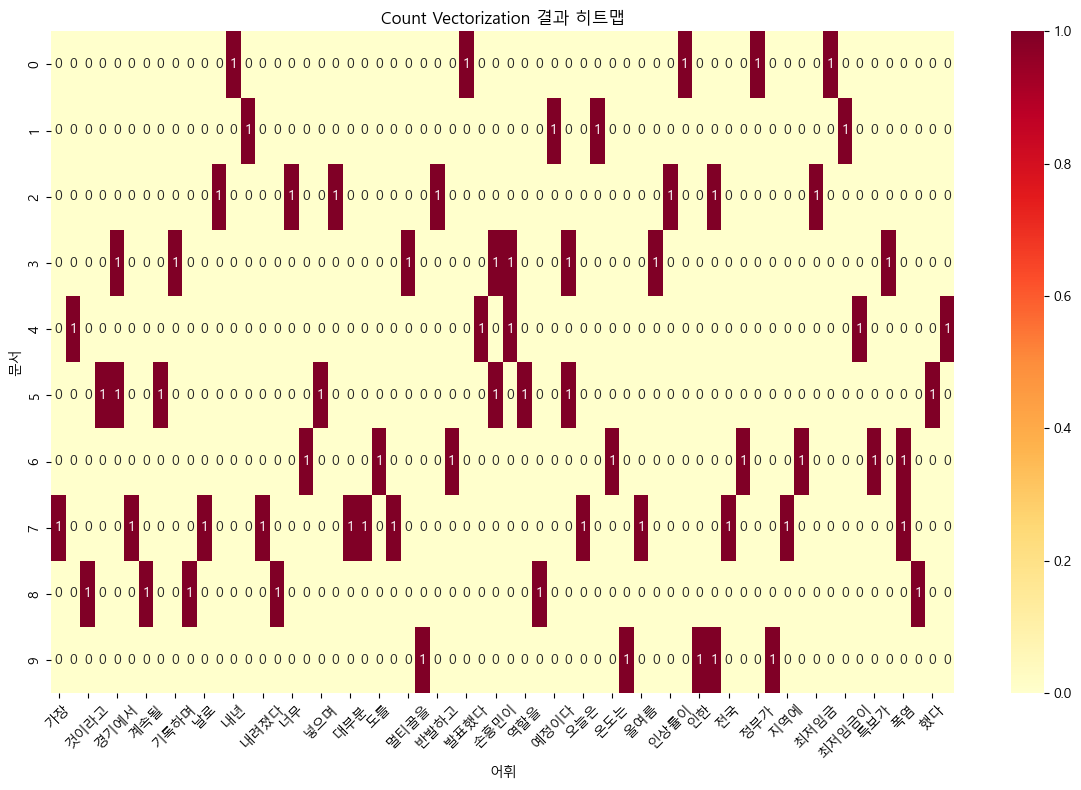

In [ ]:
count_vectorizer = CountVectorizer()
count_matrix = count_vectorizer.fit_transform(preprocessed_texts)

print("Count Vectorization 결과:")
print(f"벡터 차원: {count_matrix.shape}")
print(f"어휘: {count_vectorizer.get_feature_names_out()}\n")

count_df = pd.DataFrame(
    count_matrix.toarray(), 
    columns=count_vectorizer.get_feature_names_out()
)

# plt
plt.figure(figsize=(12, 8))
sns.heatmap(count_df, annot=True, cmap='YlOrRd', fmt='d')
plt.title('Count Vectorization 결과 히트맵')
plt.xlabel('어휘')
plt.ylabel('문서')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

TF-IDF Vectorization 결과:
벡터 차원: (10, 62)
어휘: ['가장' '거두었다' '것이라고' '결정적인' '경기에서' '경보가' '계속될' '골을' '기록하며' '기상청은' '날로'
 '낮다고' '내년' '내년에' '내려졌다' '내일도' '너무' '넘었다' '넣으며' '노동계는' '대부분' '더운' '도를'
 '들어' '멀티골을' '무더위로' '반발하고' '발령되었으며' '발표했다' '손흥민의' '손흥민이' '승리를' '역할을'
 '예보했다' '예정이다' '오늘' '오늘은' '오를' '온도는' '온열질환자가' '올여름' '이끌었다' '인상률이' '인상하기로'
 '인한' '있다' '전국' '전국적으로' '정부가' '증가하고' '지역에' '체감' '최저임금' '최저임금을' '최저임금이'
 '토트넘은' '특보가' '팀의' '폭염' '폭염이' '했다' '활약으로']

TF-IDF 결과 테이블:
      가장  거두었다   것이라고   결정적인   경기에서    경보가    계속될     골을   기록하며   기상청은  ...  \
0  0.000  0.00  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  ...   
1  0.000  0.00  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  ...   
2  0.000  0.00  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  ...   
3  0.000  0.00  0.000  0.000  0.324  0.000  0.000  0.000  0.381  0.000  ...   
4  0.000  0.46  0.000  0.000  0.000  0.000  0.000  0.000  0.000  0.000  ...   
5  0.000  0.00  0.000  0.374  0.318  0.000  0.000  0.374  0.000  0.

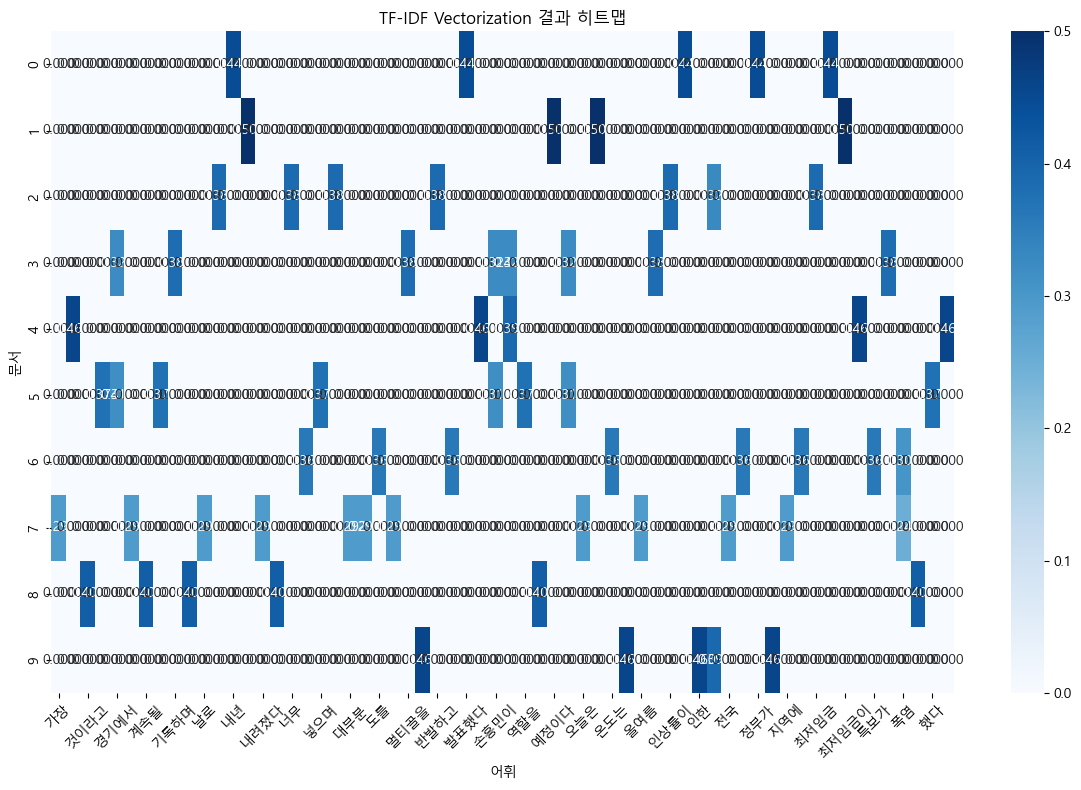

In [ ]:
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(preprocessed_texts)

print("TF-IDF Vectorization 결과:")
print(f"벡터 차원: {tfidf_matrix.shape}")
print(f"어휘: {tfidf_vectorizer.get_feature_names_out()}\n")

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(), 
    columns=tfidf_vectorizer.get_feature_names_out()
)
print("TF-IDF 결과 테이블:")
print(tfidf_df.round(3))

# plt
plt.figure(figsize=(12, 8))
sns.heatmap(tfidf_df, annot=True, cmap='Blues', fmt='.3f')
plt.title('TF-IDF Vectorization 결과 히트맵')
plt.xlabel('어휘')
plt.ylabel('문서')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

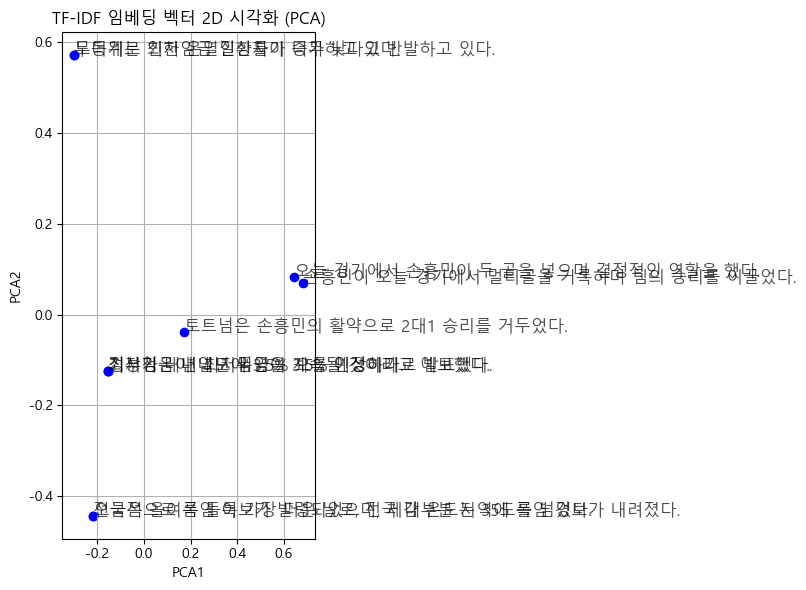

In [35]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# PCA로 2D로 차원 축소
pca = PCA(n_components=2)
pca_result = pca.fit_transform(tfidf_matrix.toarray())

# 시각화
plt.figure(figsize=(8, 6))
plt.scatter(pca_result[:, 0], pca_result[:, 1], marker='o', color='blue')

# 각 점에 텍스트 추가
for i, txt in enumerate(texts):
    plt.annotate(txt, (pca_result[i, 0], pca_result[i, 1]), fontsize=12, alpha=0.7)

plt.title('TF-IDF 임베딩 벡터 2D 시각화 (PCA)')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.grid(True)
plt.tight_layout()
plt.show()

문서 간 코사인 유사도:
       문서 1  문서 2      문서 3      문서 4     문서 5      문서 6      문서 7      문서 8  \
문서 1    1.0   0.0  0.000000  0.000000  0.00000  0.000000  0.000000  0.000000   
문서 2    0.0   1.0  0.000000  0.000000  0.00000  0.000000  0.000000  0.000000   
문서 3    0.0   0.0  1.000000  0.000000  0.00000  0.000000  0.000000  0.000000   
문서 4    0.0   0.0  0.000000  1.000000  0.12668  0.308479  0.000000  0.000000   
문서 5    0.0   0.0  0.000000  0.126680  1.00000  0.000000  0.000000  0.000000   
문서 6    0.0   0.0  0.000000  0.308479  0.00000  1.000000  0.000000  0.000000   
문서 7    0.0   0.0  0.000000  0.000000  0.00000  0.000000  1.000000  0.075951   
문서 8    0.0   0.0  0.000000  0.000000  0.00000  0.000000  0.075951  1.000000   
문서 9    0.0   0.0  0.000000  0.000000  0.00000  0.000000  0.000000  0.000000   
문서 10   0.0   0.0  0.128253  0.000000  0.00000  0.000000  0.000000  0.000000   

       문서 9     문서 10  
문서 1    0.0  0.000000  
문서 2    0.0  0.000000  
문서 3    0.0  0.128253  
문서 4    0

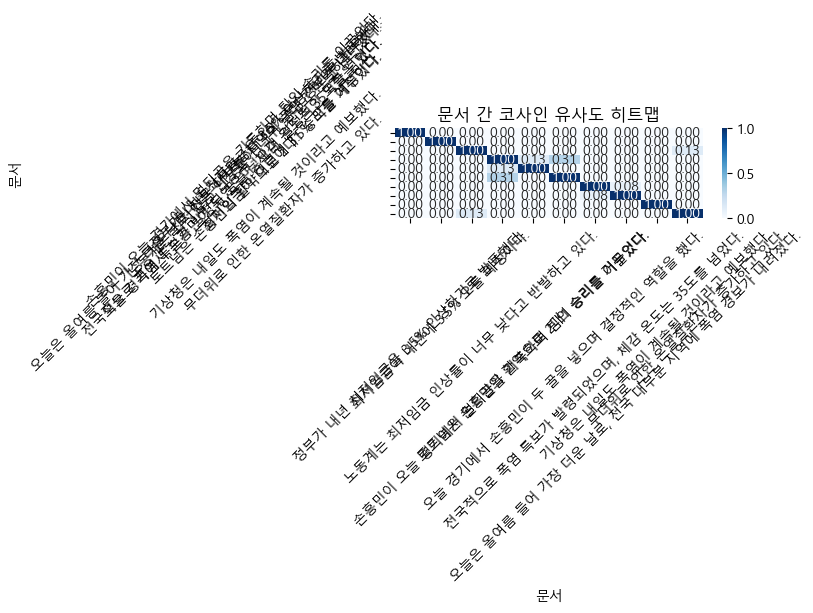

In [36]:
from sklearn.metrics.pairwise import cosine_similarity

# 문서 간의 유사도 계산
cosine_similarities = cosine_similarity(tfidf_matrix)

# 결과를 데이터프레임으로 보기 좋게 출력
cosine_sim_df = pd.DataFrame(cosine_similarities, columns=[f'문서 {i+1}' for i in range(len(texts))], index=[f'문서 {i+1}' for i in range(len(texts))])

print("문서 간 코사인 유사도:")
print(cosine_sim_df)

# 유사도 행렬을 히트맵으로 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(cosine_sim_df, annot=True, cmap='Blues', fmt='.2f', xticklabels=texts, yticklabels=texts)
plt.title('문서 간 코사인 유사도 히트맵')
plt.xlabel('문서')
plt.ylabel('문서')
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()

In [37]:
# 가장 유사한 문서 찾기
most_similar_pair = cosine_sim_df.unstack().sort_values(ascending=False).drop_duplicates()
most_similar_pair = most_similar_pair[most_similar_pair < 1.0]  # 자기 자신은 제외

# 가장 유사한 문서 출력
print("\n가장 유사한 문서들:")
for pair, similarity in most_similar_pair.head(10).items():
    print(f"문서 {pair[0]}와 문서 {pair[1]}: 유사도 {similarity:.2f}")


가장 유사한 문서들:
문서 문서 4와 문서 문서 6: 유사도 0.31
문서 문서 10와 문서 문서 3: 유사도 0.13
문서 문서 4와 문서 문서 5: 유사도 0.13
문서 문서 7와 문서 문서 8: 유사도 0.08
문서 문서 8와 문서 문서 4: 유사도 0.00
